<a href="https://colab.research.google.com/github/ho891/ABCD-A/blob/20250515/yolov8_cat_counter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐱 YOLOv8로 이미지에서 고양이 수 세기
두 장의 이미지를 업로드하고 YOLOv8을 통해 고양이의 수를 자동으로 감지합니다.

In [1]:
# 1. YOLOv8 설치
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [2]:
# 2. 라이브러리 임포트
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# 3. 이미지 업로드
uploaded = files.upload()

Saving 1280＿pngtree－dogs－and－cats－png－image＿17289858 (1).png to 1280＿pngtree－dogs－and－cats－png－image＿17289858 (1).png
Saving 1280＿pngtree－cats－and－dogs－png－image＿17281259.png to 1280＿pngtree－cats－and－dogs－png－image＿17281259.png


100%|██████████| 6.25M/6.25M [00:00<00:00, 74.8MB/s]



0: 640x640 3 cats, 4 dogs, 441.6ms
Speed: 23.4ms preprocess, 441.6ms inference, 36.7ms postprocess per image at shape (1, 3, 640, 640)


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65343 (\N{FULLWIDTH LOW LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65293 (\N{FULLWIDTH HYPHEN-MINUS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


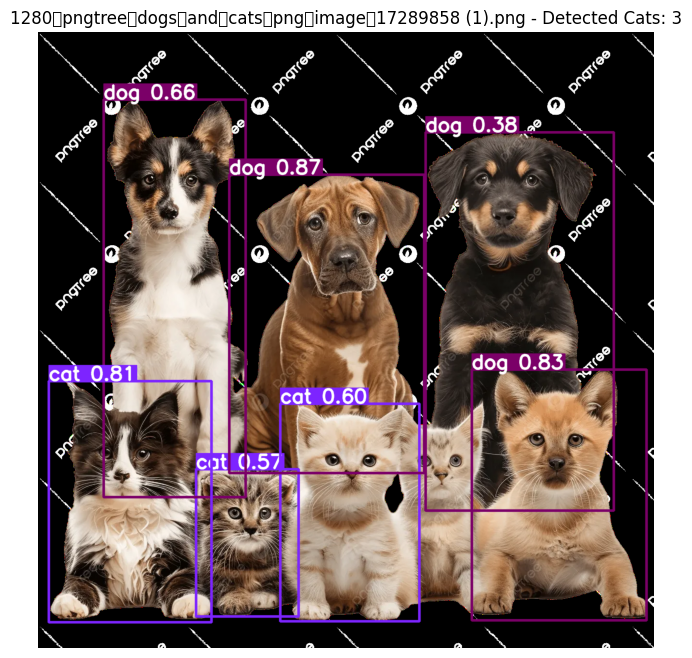


0: 640x640 3 cats, 7 dogs, 276.1ms
Speed: 6.4ms preprocess, 276.1ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


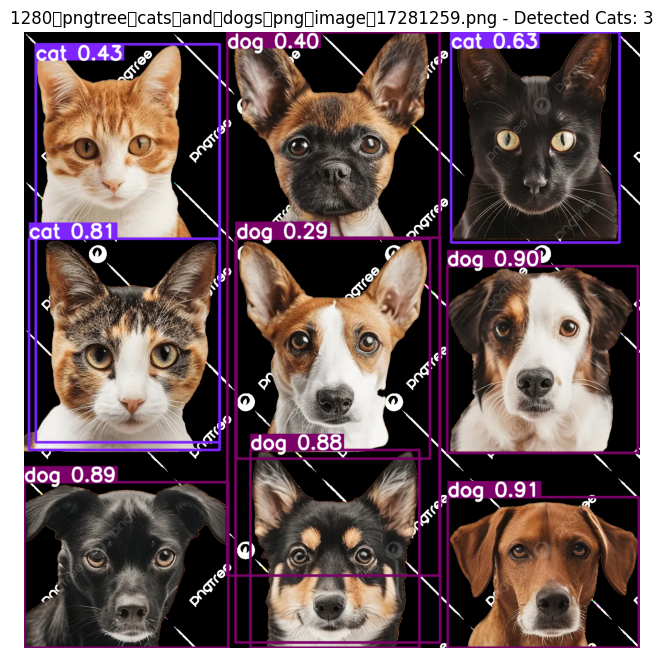

In [4]:
# 4. YOLOv8 모델 로딩 및 고양이 감지
model = YOLO("yolov8n.pt")  # Nano 모델 사용
CAT_CLASS_ID = 15  # COCO 데이터셋에서 고양이 클래스 ID

for filename in uploaded.keys():
    image = cv2.imread(filename)
    results = model(image)
    class_ids = results[0].boxes.cls.cpu().numpy().astype(int)
    cat_count = np.sum(class_ids == CAT_CLASS_ID)

    # 이미지에 박스 그리기
    annotated = results[0].plot()
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"{filename} - Detected Cats: {cat_count}")
    plt.axis('off')
    plt.show()